# Time Series

## Definition

* In time series we have explicit order dependence between observations: a time dimension
* The time dimension is both a constraint and a structure that provides a source of additional information

```
Time #1, observation
Time #2, observation
Time #3, observation
```

![time series](img/ts1.png)

## Time Series Nomenclature

* Current time $t$, the observation at the current time
* Previous time is $(t-1)$ - past
* The time before that $(t-2)$ -past
* $...$
* The next time is $(t+1)$ - future

## Datasets
* https://www.kaggle.com/datasets/jamieleech/daily-total-female-births
* https://www.kaggle.com/datasets/paulbrabban/daily-minimum-temperatures-in-melbourne


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
series = pd.read_csv("data/daily-minimum-temperatures-in-me.csv")
type(series)

pandas.core.frame.DataFrame

In [ ]:
series.head()

In [10]:
series.dtypes

Date                                                              object
Daily minimum temperatures in Melbourne, Australia, 1981-1990    float64
dtype: object

## Time Series

In [11]:
series['Date'] = pd.to_datetime(series['Date'])

In [12]:
series.dtypes

Date                                                             datetime64[ns]
Daily minimum temperatures in Melbourne, Australia, 1981-1990           float64
dtype: object

In [13]:
series.head()

,Date,"Daily minimum temperatures in Melbourne, Australia, 1981-1990"
0,1981-01-01,20.7
1,1981-01-02,17.9
2,1981-01-03,18.8
3,1981-01-04,14.6
4,1981-01-05,15.8


In [15]:
series.Date.dt.day_name()

0       Thursday
1         Friday
2       Saturday
3         Sunday
4         Monday
          ...   
3645    Thursday
3646      Friday
3647    Saturday
3648      Sunday
3649      Monday
Name: Date, Length: 3650, dtype: object

In [16]:
# parsing dates while loading
!head "data/daily-minimum-temperatures-in-me.csv"

"Date","Daily minimum temperatures in Melbourne, Australia, 1981-1990"
"1981-01-01",20.7
"1981-01-02",17.9
"1981-01-03",18.8
"1981-01-04",14.6
"1981-01-05",15.8
"1981-01-06",15.8
"1981-01-07",15.8
"1981-01-08",17.4
"1981-01-09",21.8


In [17]:
series2 = pd.read_csv("data/daily-minimum-temperatures-in-me.csv", parse_dates=[0])

In [19]:
series2.dtypes

Date                                                             datetime64[ns]
Daily minimum temperatures in Melbourne, Australia, 1981-1990           float64
dtype: object

In [20]:
series2.head()

,Date,"Daily minimum temperatures in Melbourne, Australia, 1981-1990"
0,1981-01-01,20.7
1,1981-01-02,17.9
2,1981-01-03,18.8
3,1981-01-04,14.6
4,1981-01-05,15.8


## EDA


In [21]:
series.describe()

,Date,"Daily minimum temperatures in Melbourne, Australia, 1981-1990"
count,3650,3650.000000
mean,1985-12-31 07:12:00,11.177753
min,1981-01-01 00:00:00,0.000000
25%,1983-07-02 06:00:00,8.300000
50%,1985-12-31 12:00:00,11.000000
75%,1988-06-30 18:00:00,14.000000
max,1990-12-31 00:00:00,26.300000
std,NaN,4.071837


In [22]:
series.isna().sum()

Date                                                             0
Daily minimum temperatures in Melbourne, Australia, 1981-1990    0
dtype: int64

<Axes: >

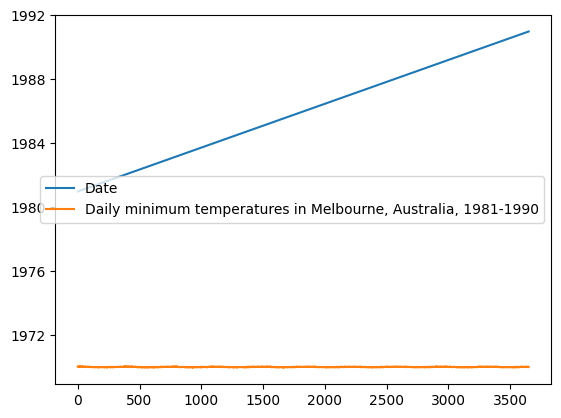

In [25]:
series.plot()

<Axes: xlabel='Date'>

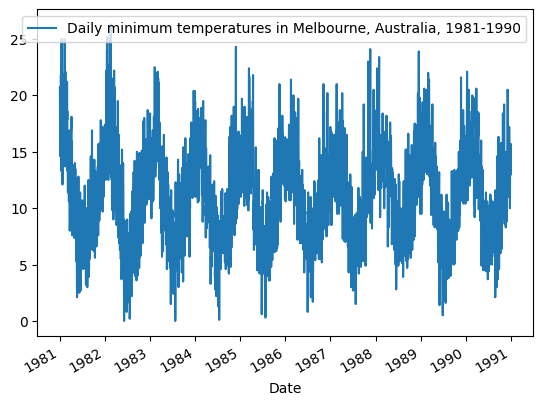

In [26]:
series.set_index("Date").plot()

In [28]:
series.set_index('Date', inplace=True)

<Axes: xlabel='Date'>

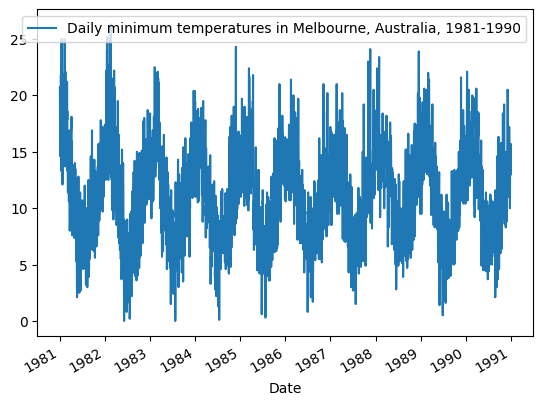

In [30]:
series.plot()

In [31]:
series.head()

,"Daily minimum temperatures in Melbourne, Australia, 1981-1990"
Date,
1981-01-01,20.7
1981-01-02,17.9
1981-01-03,18.8
1981-01-04,14.6
1981-01-05,15.8


In [32]:
series.columns

Index(['Daily minimum temperatures in Melbourne, Australia, 1981-1990'], dtype='object')

In [33]:
series.columns = ['Temperature']

<Axes: xlabel='Date'>

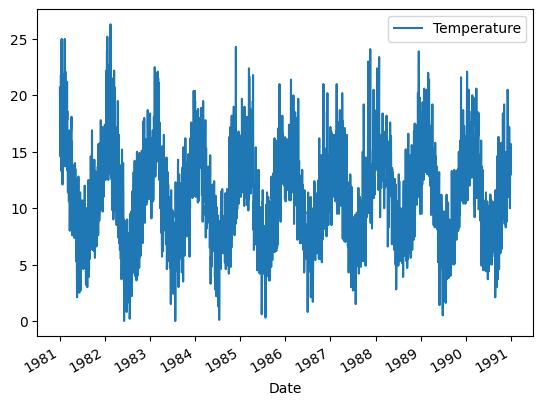

In [34]:
series.plot()

In [35]:
series.head()

,Temperature
Date,
1981-01-01,20.7
1981-01-02,17.9
1981-01-03,18.8
1981-01-04,14.6
1981-01-05,15.8


In [36]:
series2.head()

,Date,"Daily minimum temperatures in Melbourne, Australia, 1981-1990"
0,1981-01-01,20.7
1,1981-01-02,17.9
2,1981-01-03,18.8
3,1981-01-04,14.6
4,1981-01-05,15.8


In [37]:
series2.columns = ['Date', 'Temperature']

In [38]:
series2.head()

,Date,Temperature
0,1981-01-01,20.7
1,1981-01-02,17.9
2,1981-01-03,18.8
3,1981-01-04,14.6
4,1981-01-05,15.8


In [39]:
series.size

3650

In [40]:
series2.size

7300

In [41]:
series.describe()

,Temperature
count,3650.000000
mean,11.177753
std,4.071837
min,0.000000
25%,8.300000
50%,11.000000
75%,14.000000
max,26.300000


In [42]:
series.isna().sum()

Temperature    0
dtype: int64

## What can we forecast?
* Temperature
* Stocks
* Sales
* ...

**We need to have information about the past**
**Patterns**

![nasdaq](img/nasdaq-stock-market.jpg)

![time series](img/Forex2.png)

![temperature](img/ts22015.jpg)

![comet](img/comet.jpg)


![pills sale](img/pills.jpg)


## Which is easiest to forecast
* daily electricity demand in 3 days time
* time of sunrise this day next year
* Google stock price tomorrow
* Google stock price in 6 months time
* maximum temperature tomorrow
* exchange rate of \$US/€ next week
* total sales of drugs in Portuguese pharmacies next month
* timing of next Halley's comet appearance

## Which is easiest to forecast
1. time of sunrise this day next year
2. timing of next Halley's comet appearance
3. maximum temperature tomorrow
4. daily electricity demand in 3 days time
5. total sales of drugs in Portuguese pharmacies next month
6. Google stock price tomorrow
7. exchange rate of \$US/€ next week
8. Google stock price in 6 months time


## Forecastability factors
Something is easier to forecast if:
1. we have a good understanding of factor that contribute to it
2. there is lots of data available
3. the future is somewhat similar to the past
4. the forecasts cannot affect the thing we are trying to forecast

## Examples of time series data

* Four-year Olympic winning times
* Annual Google profits
* Quarterly wine production
* Monthly rainfall
* Tourism
* Hourly electricity demand

![comet](img/ts2.png)

![comet](img/ts3.png)

![comet](img/ts4.png)

## Statistical forecasting
* Thing to be forecast: a random variable, $y_t$
* Forecast distribuition: If ${\cal I}$ is all observations, then $y_{t} |{\cal I}$ means "the random variable $y_{t}$ given what we know in ${\cal I}$
* The "point forecast" is the mean (or median) of $y_t$ with high probability
* The "forecast variance" is $\text{var}[y_{t} |{\cal I}]$ is a rangeof values of $y_t$ with high probability
* A prediction interval or "interval forecast" is a range of values of $y_t$ with high probability
* With time series, ${y}_{t|t-1} = y_t | \{y_1,y_2,\dots,y_{t-1}\}$
* $\hat{y}_{T+h|T} =\text{E}[y_{T+h} | y_1,\dots,y_T]$ (an $h$-step forecast taking account of all observations up to time $T$)


## Case Study: Temperature and Female Births

In [44]:
temperature = series.copy()
female_births = pd.read_csv("data/daily-total-female-births-CA.csv")

In [46]:
female_births['date'] = pd.to_datetime(female_births['date'])

<Axes: xlabel='Date'>

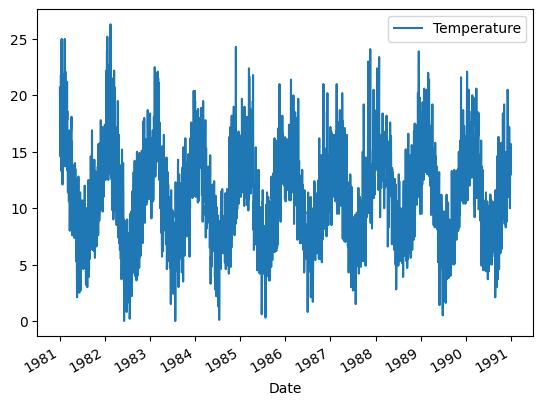

In [47]:
temperature.plot()

<Axes: xlabel='date'>

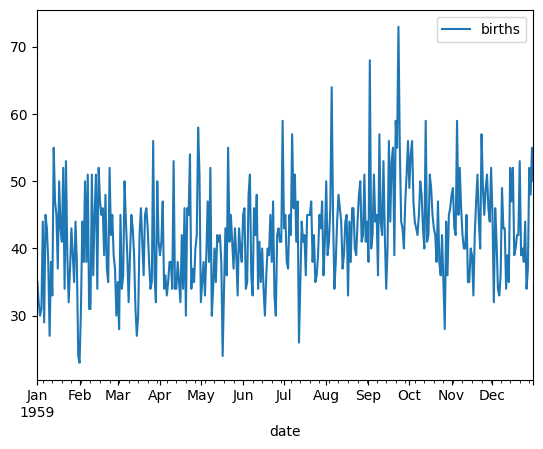

In [49]:
female_births.set_index('date').plot()

## Right now, how could we predict the temperature for next 2 years?
* 12 month average
* 6 month average
* median
* quartis
* straight line regression 12 months
* average slope between last year's and this year's values

## Practice
https://colab.research.google.com/drive/1Iw61k5fciRb38FQFANqTzTKeUo_-eZ0H?usp=sharing

In [50]:
import yfinance as yf

data = yf.download("AAPL", start="2023-01-01", end="2025-01-01")
print(data.head())

/Users/gabrielasoares/.local/share/virtualenvs/2025-2-PQSh4Ycc/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
[*********************100%***********************]  1 of 1 completed

Price            Close        High         Low        Open     Volume
Ticker            AAPL        AAPL        AAPL        AAPL       AAPL
Date                                                                 
2023-01-03  123.768471  129.537796  122.877835  128.924252  112117500
2023-01-04  125.045044  127.321112  123.778365  125.569527   89113600
2023-01-05  123.718979  126.440361  123.461690  125.807022   80962700
2023-01-06  128.271088  128.934113  123.590315  124.698663   87754700
2023-01-09  128.795593  132.021678  128.538304  129.112270   70790800


In [51]:
data.dtypes

Price   Ticker
Close   AAPL      float64
High    AAPL      float64
Low     AAPL      float64
Open    AAPL      float64
Volume  AAPL        int64
dtype: object

In [52]:
data = data.reset_index()
data.columns = ['Date', 'Close', 'High', 'Low', 'Open','Volume']

In [53]:
data.dtypes

Date      datetime64[ns]
Close            float64
High             float64
Low              float64
Open             float64
Volume             int64
dtype: object

In [54]:
data.set_index('Date', inplace=True)

<Axes: xlabel='Date'>

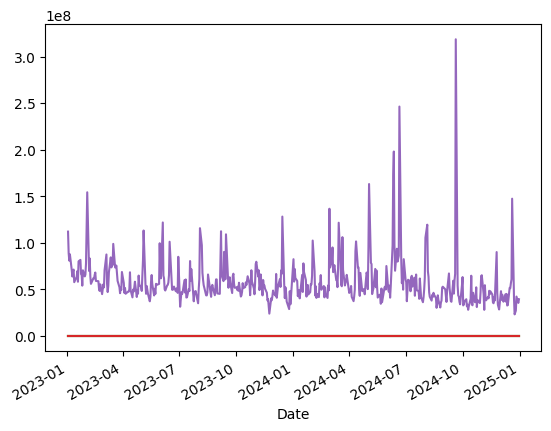

In [55]:
data['Close'].plot()
data['High'].plot()
data['Low'].plot()
data['Open'].plot()
data['Volume'].plot()

# Exercise

1. Chose any of the methods discussed previously (mean, median, 12 month average, etc.) to forecast 15 days of any of the following columns: Close, Open, High, Low or Volume

